### EDA: Overall Distribution, Delay by Train/Station

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}"
    f"@{os.getenv('MYSQL_HOST')}/{os.getenv('MYSQL_DATABASE')}"
)
 
os.makedirs("figures", exist_ok=True)

### Delay by Minutes

In [3]:
summary_query = """
SELECT
    COUNT(*) AS n_records,
    AVG(delay_minutes) AS mean_delay,
    STDDEV(delay_minutes) AS std_delay,
    MIN(delay_minutes) AS min_delay,
    MAX(delay_minutes) AS max_delay
FROM delays
"""
summary = pd.read_sql(text(summary_query), engine)
print(summary)

   n_records  mean_delay  std_delay  min_delay  max_delay
0     174988    42.17784  50.080166      -88.0     2774.0


#### Median in Pandas (As MySQL doesn't have a built in MEDIAN aggregate)

In [4]:
delay_series = pd.read_sql(text("SELECT delay_minutes FROM delays;"), engine)["delay_minutes"]
print("Median delay:", delay_series.median())

Median delay: 30.0


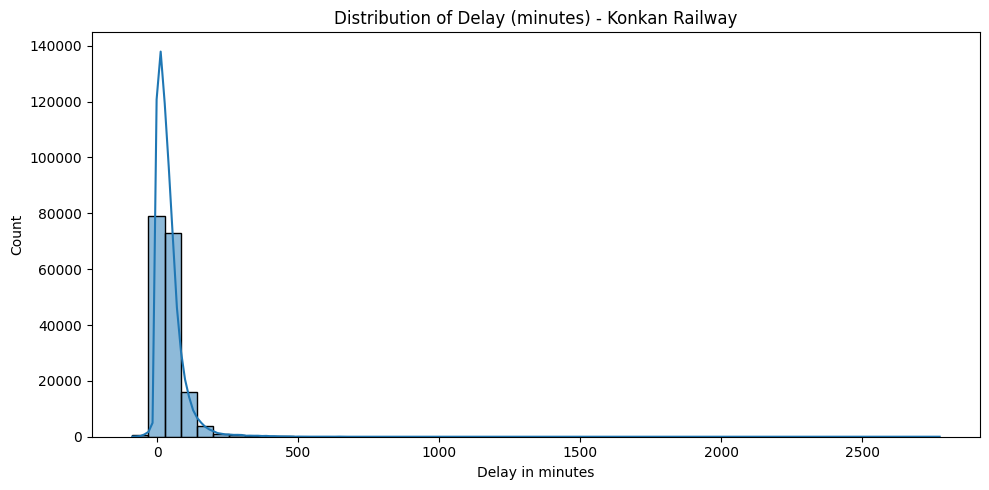

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(delay_series, bins=50, kde=True)
plt.title("Distribution of Delay (minutes) - Konkan Railway")
plt.xlabel("Delay in minutes")
plt.tight_layout()
plt.savefig("figures/delay_histogram.png")
plt.show()

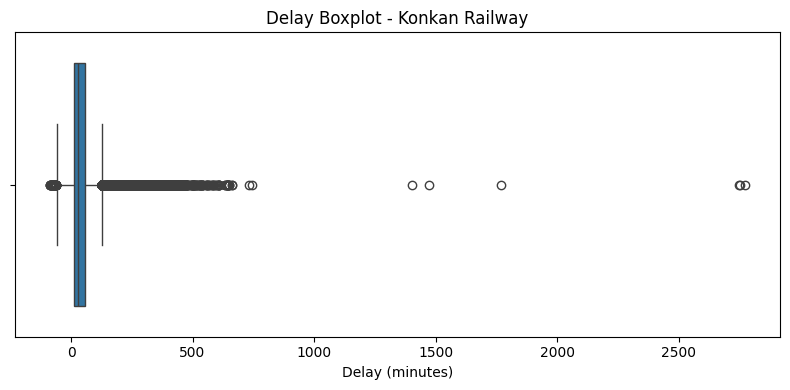

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=delay_series)
plt.title("Delay Boxplot - Konkan Railway")
plt.xlabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("figures/delay_boxplot.png")

### Delay by Train Number

In [7]:
train_query = """
SELECT
    t.train_no, t.train_name, t.type_code, t.coverage_tier,
    COUNT(*) AS n_records,
    AVG(d.delay_minutes) AS avg_delay,
    STDDEV(d.delay_minutes) AS std_delay
FROM delays d
JOIN trains t ON t.train_no = d.train_no
GROUP BY t.train_no, t.train_name, t.type_code, t.coverage_tier
ORDER BY avg_delay DESC;
"""
train_delay = pd.read_sql(text(train_query), engine)
print(train_delay.head(10))

   train_no        train_name   type_code coverage_tier  n_records  avg_delay  \
0     12450   GOA SMPRK K EXP   SF-TRAINS           Low        630   86.73968   
1     22475    HSR CBE AC EXP   SF-TRAINS           Low        581   80.60585   
2     12134   MAJN CSMT SF EX   SF-TRAINS          High       5312   76.55629   
3     10103   MANDOVI EXPRESS  EXP-TRAINS          High       7297   72.30437   
4     22114   KCVL LTT SF EXP   SF-TRAINS           Low       1352   66.91124   
5     12618   MNGLA LKSDP EXP   SF-TRAINS          High       5110   63.60705   
6     12619  MATSYAGANDHA EXP   SF-TRAINS          High       8030   59.70660   
7     22120     TEJAS EXPRESS  PRM-TRAINS        Medium       1922   59.31217   
8     16345     NETRAVATI EXP  EXP-TRAINS          High       7842   57.56503   
9     22115   LTT KRMI AC SUP   SF-TRAINS           Low        371   54.17520   

    std_delay  
0  103.031951  
1   59.724277  
2   83.319778  
3   75.614366  
4   70.799008  
5   66.12962

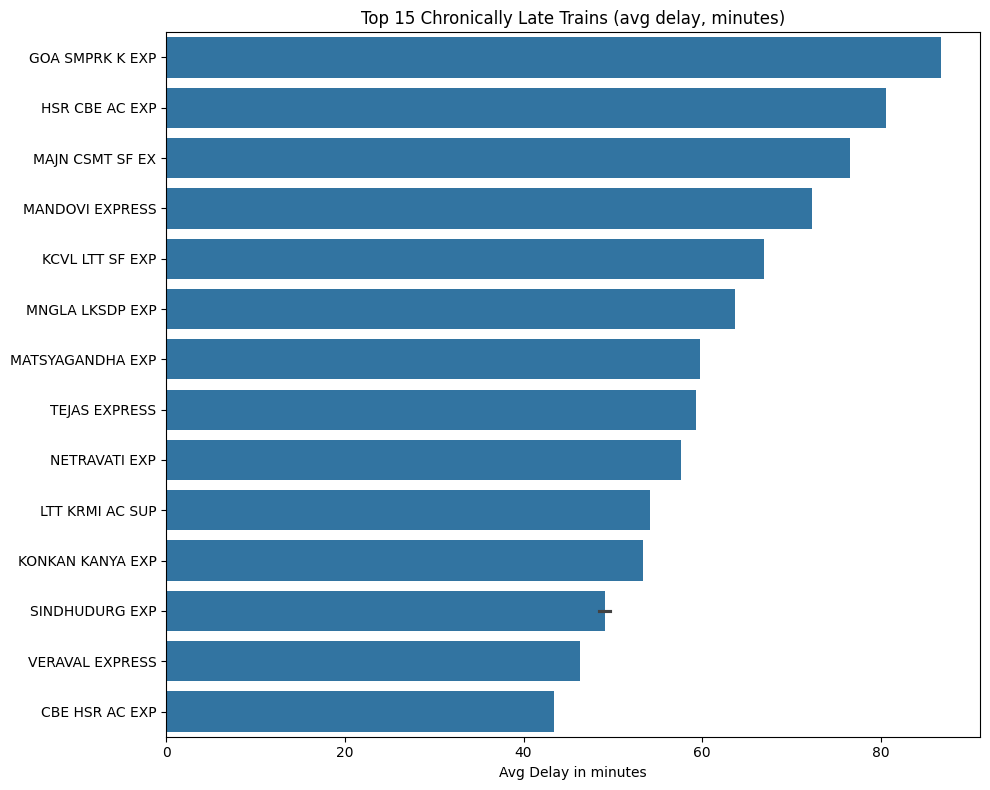

In [8]:
top15_trains = train_delay.head(15)
plt.figure(figsize=(10, 8))
sns.barplot(data=top15_trains, y="train_name", x="avg_delay")
plt.title("Top 15 Chronically Late Trains (avg delay, minutes)")
plt.xlabel("Avg Delay in minutes")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/top_trains_delay.png")
plt.show()

In [9]:
train_delay_high = train_delay[train_delay["coverage_tier"] == "High"].sort_values("avg_delay", ascending=False)
print(train_delay_high.head(10))

    train_no        train_name   type_code coverage_tier  n_records  \
2      12134   MAJN CSMT SF EX   SF-TRAINS          High       5312   
3      10103   MANDOVI EXPRESS  EXP-TRAINS          High       7297   
5      12618   MNGLA LKSDP EXP   SF-TRAINS          High       5110   
6      12619  MATSYAGANDHA EXP   SF-TRAINS          High       8030   
8      16345     NETRAVATI EXP  EXP-TRAINS          High       7842   
10     20111  KONKAN KANYA EXP   SF-TRAINS          High       6932   
11     10105    SINDHUDURG EXP  EXP-TRAINS          High      11494   
12     10106    SINDHUDURG EXP  EXP-TRAINS          High      11494   
16     11004    TUTARI EXPRESS  EXP-TRAINS          High       7454   
17     12617   MANGLADWEEP EXP   SF-TRAINS          High       5110   

    avg_delay  std_delay  
2    76.55629  83.319778  
3    72.30437  75.614366  
5    63.60705  66.129620  
6    59.70660  65.623042  
8    57.56503  50.117698  
10   53.36887  44.233923  
11   49.68357  37.408879  
12

In [10]:
station_query = """
SELECT
    s.station_code, s.station_full_name, s.station_zone,
    COUNT(*) AS n_records,
    AVG(delay_minutes) AS avg_delay
FROM delays d
JOIN stations s ON d.station_code = s.station_code
GROUP BY s.station_code, s.station_full_name, s.station_zone
ORDER BY avg_delay DESC;
"""
station_delay = pd.read_sql(text(station_query), engine)
print(station_delay.head(15))

   station_code station_full_name station_zone  n_records  avg_delay
0           NIV           NIVASAR           KR        730   67.07808
1           ANO            ANJANI           KR        390   66.70000
2          VRLI          VERAVALI           KR        730   61.32603
3           KKW         KANKAVALI           KR       5287   60.78608
4          KRMI           KARMALI           KR       3942   60.74353
5          THVM            THIVIM           KR       4061   59.15169
6          ADVI           ADAVALI           KR       2190   57.89772
7          RAJP      RAJAPUR ROAD           KR       3274   57.52046
8          PERN            PERNEM           KR       1773   57.42809
9          KUDL             KUDAL           KR       4985   57.42287
10         SNDD        SINDHUDURG           KR       3232   56.01021
11          VBW    VAIBHAVWADI RD           KR       2920   56.00274
12         VINH           VINHERE           KR        730   55.25616
13          SGR       SANGMESHWAR 

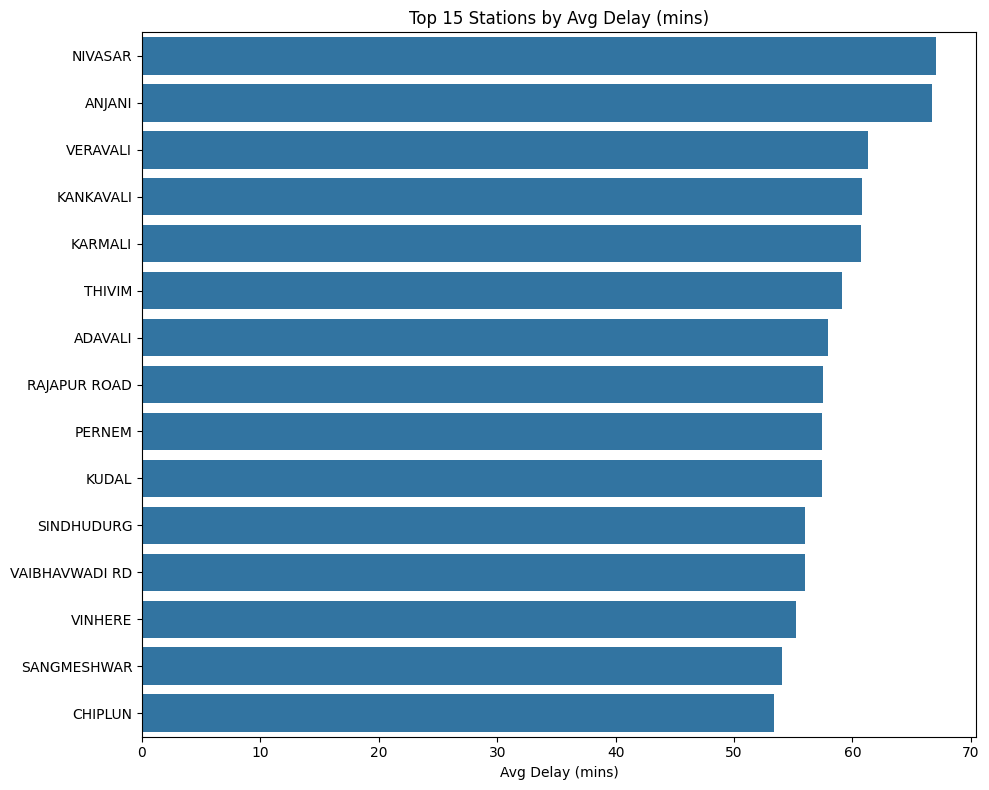

In [11]:
top15_stations = station_delay.head(15)
plt.figure(figsize=(10, 8))
sns.barplot(data=top15_stations, y="station_full_name", x="avg_delay")
plt.title("Top 15 Stations by Avg Delay (mins)")
plt.xlabel("Avg Delay (mins)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/top_stations_delay.png")
plt.show()

In [12]:
q = "SELECT station_code FROM stations;"
s = pd.read_sql(text(q), engine)
codes = s["station_code"].tolist()
codes

['ABR',
 'ACRN',
 'ADI',
 'ADVI',
 'AGC',
 'AKV',
 'ALLP',
 'AMPA',
 'ANKL',
 'ANND',
 'ANO',
 'APTA',
 'AT',
 'AVRD',
 'AWY',
 'BAU',
 'BAW',
 'BDJ',
 'BDTS',
 'BGNR',
 'BINA',
 'BIRD',
 'BKJ',
 'BKN',
 'BKNG',
 'BL',
 'BNC',
 'BNTL',
 'BOR',
 'BPL',
 'BRC',
 'BSL',
 'BSR',
 'BTJL',
 'BVI',
 'BYNR',
 'CAN',
 'CBE',
 'CDG',
 'CHI',
 'CHV',
 'CLT',
 'CNGR',
 'CNO',
 'CNPA',
 'CPT',
 'CSMT',
 'CUR',
 'CVP',
 'DG',
 'DINR',
 'DIVA',
 'DR',
 'ED',
 'ERN',
 'ERS',
 'ET',
 'FA',
 'FDB',
 'FK',
 'GDL',
 'GIMB',
 'GNO',
 'GOK',
 'GWL',
 'HAA',
 'HAD',
 'HAS',
 'HLN',
 'HNA',
 'HSR',
 'JITE',
 'JND',
 'JU',
 'KAWR',
 'KBPR',
 'KFD',
 'KGI',
 'KGQ',
 'KHED',
 'KIGL',
 'KKW',
 'KLMC',
 'KNW',
 'KOL',
 'KOTA',
 'KPQ',
 'KPY',
 'KRMI',
 'KRNR',
 'KRPN',
 'KRR',
 'KSD',
 'KT',
 'KTU',
 'KTYM',
 'KUDA',
 'KUDL',
 'KYJ',
 'KYN',
 'KZE',
 'LTT',
 'LUNI',
 'MAJN',
 'MAN',
 'MANK',
 'MAO',
 'MAQ',
 'MDU',
 'MJ',
 'MMR',
 'MNI',
 'MRA',
 'MRDW',
 'MRJN',
 'MSH',
 'MTD',
 'MTJ',
 'MULK',
 'MVLK',
 'MYA',
 